In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("tips.csv")
df

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


In [3]:
df.groupby("day")['tip'].sum()

,tip
day,
Fri,51.96
Sat,260.40
Sun,247.39
Thur,171.83


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    object 
 4   smoker      244 non-null    object 
 5   day         244 non-null    object 
 6   time        244 non-null    object 
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [6]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
display(df.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


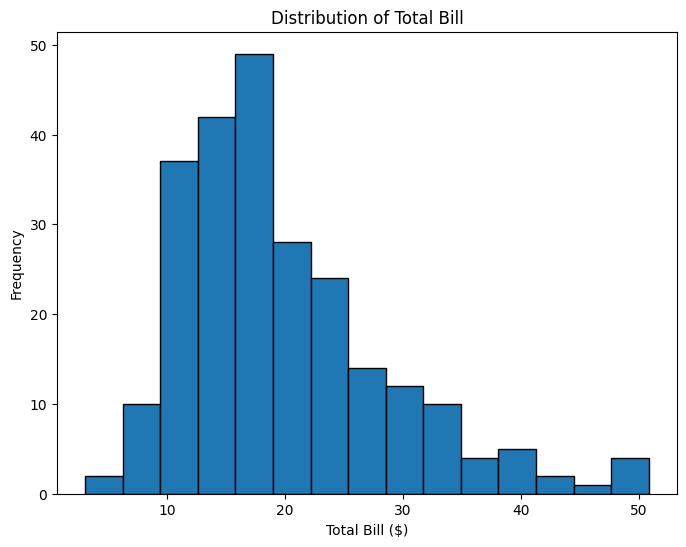

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(df['total_bill'], bins=15, edgecolor='black') # Using matplotlib's hist function
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.show()

In [9]:
# bar plot

In [10]:
# plt.bar(x,values)
# plt.barh(x,values)

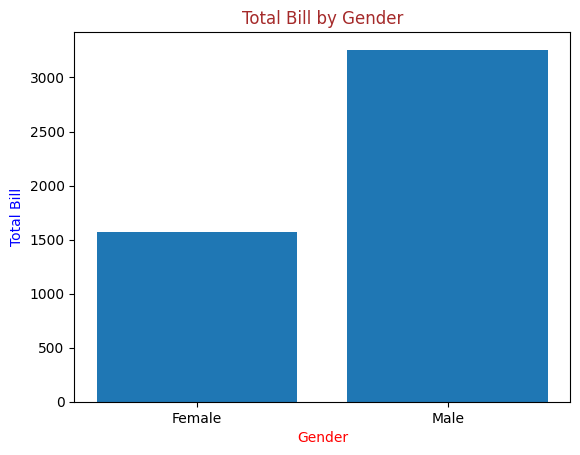

In [24]:
data=df.groupby('sex')['total_bill'].sum().reset_index()
data=pd.DataFrame(data)
plt.bar(data['sex'],data['total_bill'])
plt.xlabel('Gender',color='red')
plt.ylabel('Total Bill',color='blue')
plt.title('Total Bill by Gender',color='brown')
plt.show()

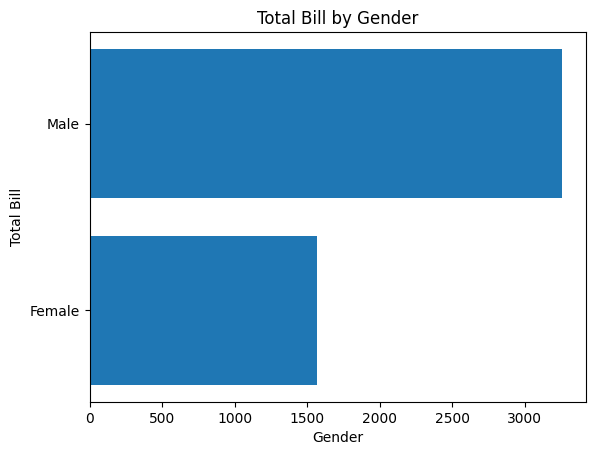

In [15]:
data=df.groupby('sex')['total_bill'].sum().reset_index()
data=pd.DataFrame(data)
plt.barh(data['sex'],data['total_bill'])
plt.xlabel('Gender')
plt.ylabel('Total Bill')
plt.title('Total Bill by Gender')
plt.show()

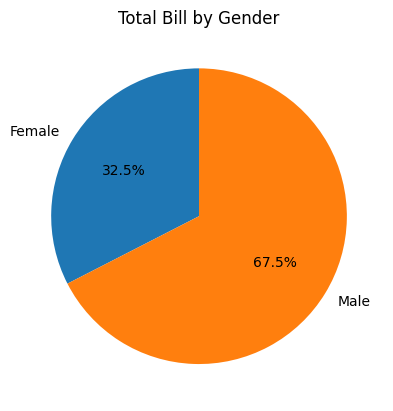

In [17]:
data=df.groupby('sex')['total_bill'].sum().reset_index()
data=pd.DataFrame(data)
plt.pie(data['total_bill'], labels=data['sex'], autopct='%1.1f%%', startangle=90)
plt.title('Total Bill by Gender')
plt.show()

In [26]:
# total sales of weekend
weekend_sales = df[df['day'].isin(['Sat', 'Sun'])]['total_bill'].sum()

Total sales of weekend: $3405.56


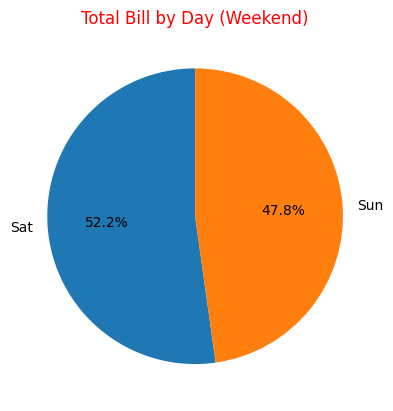

In [34]:
import matplotlib.pyplot as plt

# Filter for weekend and group data
weekend_sales = df[df['day'].isin(['Sat', 'Sun'])]
data = weekend_sales.groupby('day')['total_bill'].sum().reset_index()

# Create pie chart: values first, then labels
plt.pie(data['total_bill'], labels=data['day'], autopct='%1.1f%%', startangle=90)
plt.title('Total Bill by Day (Weekend)', color='red')
plt.show()

In [57]:
# person smoking or non smoking
# hatch=['*','/']

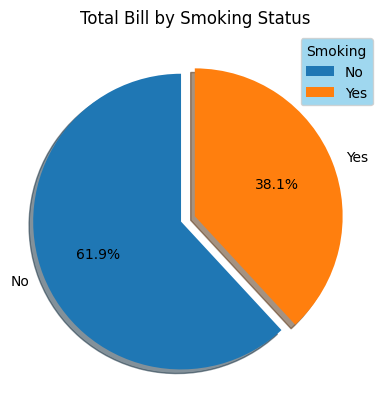

In [58]:
sm = df.groupby('smoker')['total_bill'].count().reset_index()
plt.pie(sm['total_bill'], labels=sm['smoker'], autopct='%1.1f%%', startangle=90, explode=[0.1, 0], shadow=True)
plt.legend(loc='best', title='Smoking', facecolor='skyblue')
plt.title('Total Bill by Smoking Status')
plt.show()

In [59]:
# total bill based on each and every day

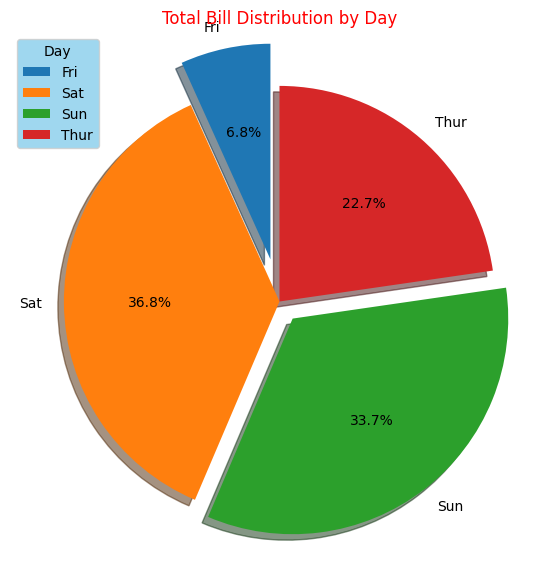

In [61]:
day_by_day = df.groupby('day')['total_bill'].sum().reset_index()

plt.figure(figsize=(10, 7))
# Use the 'day' column specifically for labels
plt.pie(day_by_day['total_bill'],
        labels=day_by_day['day'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.2, 0, 0.1, 0],
        shadow=True)

plt.title('Total Bill Distribution by Day', color='red')
plt.legend(loc='upper left', title='Day', facecolor='skyblue')
plt.show()

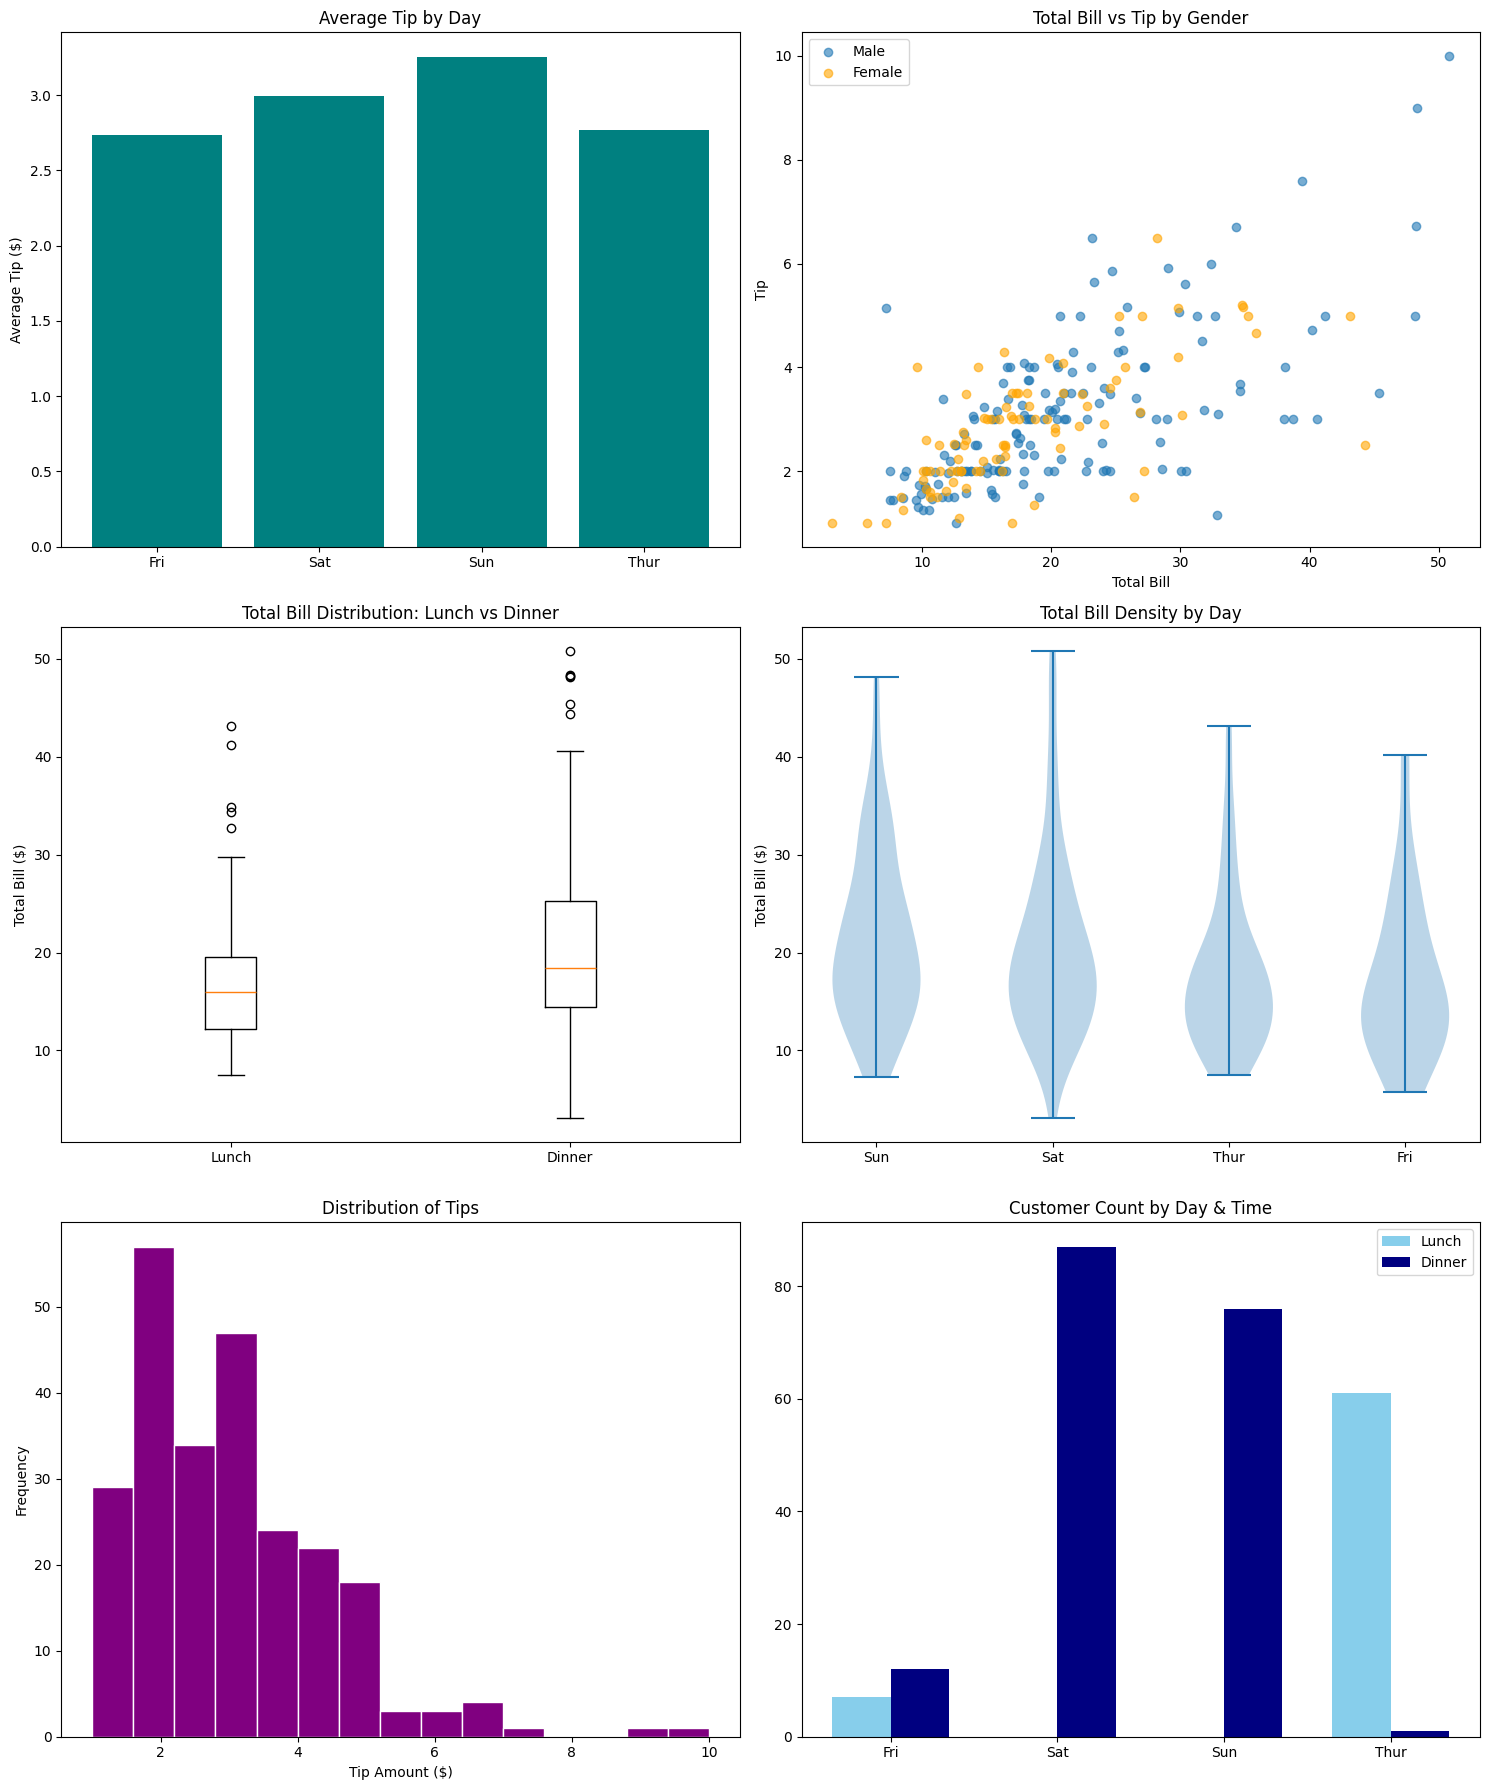

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with subplots (3 rows, 2 columns)
fig = plt.figure(figsize=(15, 18))

# 1. Bar Graph: Average Tip per Day
plt.subplot(3, 2, 1)
avg_tip = df.groupby('day')['tip'].mean().reset_index()
plt.bar(avg_tip['day'], avg_tip['tip'], color='teal')
plt.title('Average Tip by Day')
plt.ylabel('Average Tip ($)')

# 2. Scatter Plot: Total Bill vs Tip by Gender
plt.subplot(3, 2, 2)
male_subset = df[df['sex'] == 'Male']
female_subset = df[df['sex'] == 'Female']
plt.scatter(male_subset['total_bill'], male_subset['tip'], label='Male', alpha=0.6)
plt.scatter(female_subset['total_bill'], female_subset['tip'], label='Female', alpha=0.6, color='orange')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip by Gender')
plt.legend()

# 3. Box Plot: Total Bill Distribution by Time
plt.subplot(3, 2, 3)
lunch = df[df['time'] == 'Lunch']['total_bill']
dinner = df[df['time'] == 'Dinner']['total_bill']
plt.boxplot([lunch, dinner], tick_labels=['Lunch', 'Dinner'])
plt.title('Total Bill Distribution: Lunch vs Dinner')
plt.ylabel('Total Bill ($)')

# 4. Violin Plot: Total Bill by Day
plt.subplot(3, 2, 4)
days = df['day'].unique()
data_to_plot = [df[df['day'] == d]['total_bill'] for d in days]
plt.violinplot(data_to_plot)
plt.xticks(range(1, len(days) + 1), days)
plt.title('Total Bill Density by Day')
plt.ylabel('Total Bill ($)')

# 5. Histogram: Distribution of Tips (New Graph 1)
plt.subplot(3, 2, 5)
plt.hist(df['tip'], bins=15, color='purple', edgecolor='white')
plt.title('Distribution of Tips')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')

# 6. Grouped Bar Chart: Customer Count by Day and Time (New Graph 2)
plt.subplot(3, 2, 6)
counts = df.groupby(['day', 'time']).size().unstack().fillna(0)
raw_days = counts.index
x = np.arange(len(raw_days))
width = 0.35
plt.bar(x - width/2, counts['Lunch'], width, label='Lunch', color='skyblue')
plt.bar(x + width/2, counts['Dinner'], width, label='Dinner', color='navy')
plt.xticks(x, raw_days)
plt.title('Customer Count by Day & Time')
plt.legend()

plt.tight_layout()
plt.show()

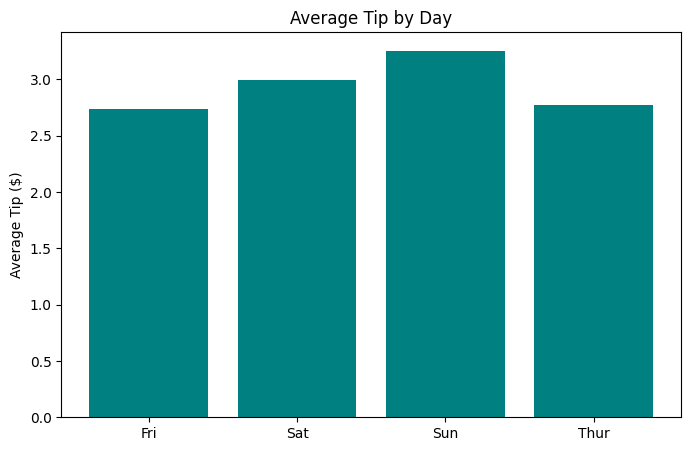

In [62]:
# 1. Average tip per day (Bar Graph)
avg_tip = df.groupby('day')['tip'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(avg_tip['day'], avg_tip['tip'], color='teal')
plt.title('Average Tip by Day')
plt.ylabel('Average Tip ($)')
plt.show()

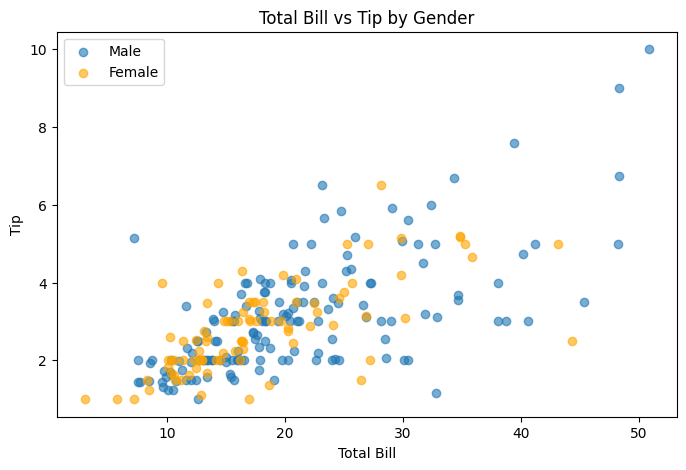

In [63]:
# 2. Total Bill vs Tip for Male vs Female (Scatter Plot)
male_subset = df[df['sex'] == 'Male']
female_subset = df[df['sex'] == 'Female']

plt.figure(figsize=(8, 5))
plt.scatter(male_subset['total_bill'], male_subset['tip'], label='Male', alpha=0.6)
plt.scatter(female_subset['total_bill'], female_subset['tip'], label='Female', alpha=0.6, color='orange')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip by Gender')
plt.legend()
plt.show()

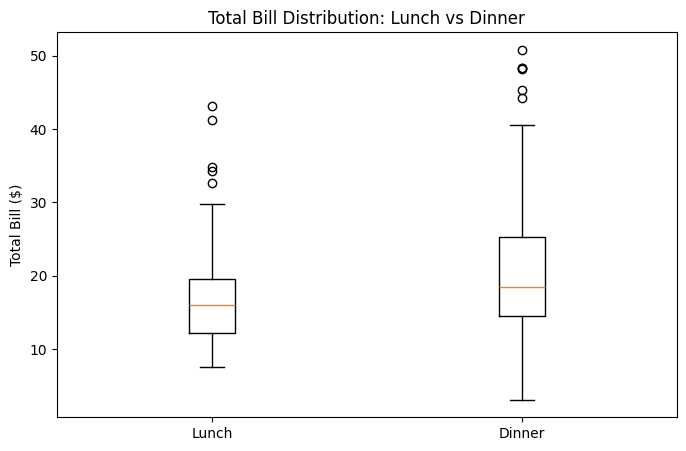

In [65]:
# 3. Distribution of Total Bill by Time (Box Plot using Matplotlib)
lunch = df[df['time'] == 'Lunch']['total_bill']
dinner = df[df['time'] == 'Dinner']['total_bill']

plt.figure(figsize=(8, 5))
# Using 'tick_labels' to avoid DeprecationWarning
plt.boxplot([lunch, dinner], tick_labels=['Lunch', 'Dinner'])
plt.title('Total Bill Distribution: Lunch vs Dinner')
plt.ylabel('Total Bill ($)')
plt.show()